# Intrusion Detection System — Modelling (Part 4: Multi-class, MLP from scratch)
### Dataset: CICIDS-2017  ·  Runs on **Kaggle**

Multi-class extension of `07_Modeling_Binary_MLP.ipynb`. Same scratch implementation, different output head: **softmax over 7 classes + categorical cross-entropy** in place of sigmoid + BCE.

**Architecture:** input(47) → Dense → ReLU → Dropout → Dense → ReLU → Dropout → Dense(7) → Softmax.

**Why this notebook matters.** The softmax-LR multi-class run plateaued at **macro-F1 = 0.7527**, with the rare classes failing hard:
- Web Attack: F1 = 0.408 (precision 0.26 — 96% false-alarm rate)
- Bot/Infiltration: F1 = 0.073 (precision 0.04 — basically broken)

A linear model cannot carve out 1,500-row classes in 47-D space. An MLP with non-linearity *can* — if any model in this project will close the rare-class gap, it's this one. That's the headline question this notebook answers.

**This notebook:**
| # | Section | Notes |
|---|---------|-------|
| 1 | Setup | Kaggle paths, report helpers |
| 2 | Data Journey + Load | both training strategies (real + capped SMOTE), shared real-world test |
| 3 | `MLPMulticlassScratch` | softmax output + categorical CE + hand-derived backprop |
| 4 | Smoke test | sanity-check the implementation learns |
| 5 | Grid search | architectures × lr × dropout, ranked by **macro-F1** |
| 6 | SMOTE vs class-weighting | retrain best config both ways, side-by-side + per-class |
| 7 | **Softmax LR vs MLP** | the headline — does non-linearity rescue the rare classes? |
| 8 | Save | weights + metrics + figures |

**Kaggle setup:** same FeatureSelection output dataset — `train_selected.parquet`, `train_multi_smote_selected.parquet`, `test_selected.parquet`, `selected_features.json`. Set `IN_DIR` to its mount path. No `pip install` needed.

## 1. Imports, Config & Report Helpers

In [1]:
import os, json, time, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# label mapping — matches the FeatureSelection output / Modeling_Multiclass notebook
CLASS_NAMES = ['BENIGN', 'Bot/Infiltration', 'Brute Force', 'DDoS',
               'DoS', 'PortScan', 'Web Attack']
N_CLASSES   = len(CLASS_NAMES)

# ── Kaggle paths ───────────────────────────────────────────────────
# IN_DIR : Kaggle Dataset / Notebook Output holding FeatureSelection.ipynb results
#   ----> EDIT to match the mount path shown in the Kaggle 'Input' panel.
IN_DIR      = '/kaggle/input/datasets/hanzlahmunir/fs-output'
OUT_DIR     = '/kaggle/working'
FIGURES_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── report helpers ─────────────────────────────────────────────────
_report_lines = []

def _log(text=''):
    _report_lines.append(str(text))
    print(text)

def _savefig(name, fig=None):
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt).savefig(path, dpi=130, bbox_inches='tight')
    return path

def write_report():
    path = os.path.join(OUT_DIR, 'Modeling_Multiclass_MLP_Report.txt')
    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(_report_lines))
    print(f'\nReport saved -> {path}')

_log('=' * 70)
_log('MODELLING REPORT (MULTI-CLASS, MLP)  —  CICIDS-2017')
_log('Model : Multi-Layer Perceptron (from scratch, NumPy, softmax output)')
_log(f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
_log('=' * 70)
print('\nSetup complete.')
print('  Reading from :', IN_DIR)
print('  Writing to   :', OUT_DIR)

MODELLING REPORT (MULTI-CLASS, MLP)  —  CICIDS-2017
Model : Multi-Layer Perceptron (from scratch, NumPy, softmax output)
Generated : 2026-05-15 13:24

Setup complete.
  Reading from : /kaggle/input/datasets/hanzlahmunir/fs-output
  Writing to   : /kaggle/working


## 2. Load Data — Both Imbalance Strategies
Same data as the softmax-LR multi-class notebook so the LR-vs-MLP comparison in Section 7 is apples-to-apples.

In [2]:
train_path = os.path.join(IN_DIR, 'train_selected.parquet')
smote_path = os.path.join(IN_DIR, 'train_multi_smote_selected.parquet')
test_path  = os.path.join(IN_DIR, 'test_selected.parquet')
feat_path  = os.path.join(IN_DIR, 'selected_features.json')

for p in [train_path, smote_path, test_path, feat_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f'{p} not found. Set IN_DIR to the Kaggle mount path of your '
            'FeatureSelection output (Input panel on the right).')

with open(feat_path) as f:
    selected_features = json.load(f)['selected_features']

train_df = pd.read_parquet(train_path)
smote_df = pd.read_parquet(smote_path)
test_df  = pd.read_parquet(test_path)

X_train_full = train_df[selected_features].values.astype(np.float32)
y_train_full = train_df['label_multi'].values.astype(np.int64)
X_smote      = smote_df[selected_features].values.astype(np.float32)
y_smote      = smote_df['label_multi'].values.astype(np.int64)
X_test       = test_df[selected_features].values.astype(np.float32)
y_test       = test_df['label_multi'].values.astype(np.int64)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    random_state=RANDOM_SEED, stratify=y_train_full)

n_features = X_train_full.shape[1]

# class distribution snapshot (the 1080:1 monster from the softmax-LR notebook)
real_counts  = pd.Series(y_train_full).value_counts().sort_index()
smote_counts = pd.Series(y_smote).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()
class_table  = pd.DataFrame({
    'class':       CLASS_NAMES,
    'real_train':  real_counts.values,
    'smote_train': smote_counts.values,
    'test':        test_counts.values,
})

_log('')
_log('── SECTION 2 : DATA LOADED ────────────────────────────────')
_log(f'  Features (input dim)     : {n_features}')
_log(f'  Real train (strategy A)  : {X_train_full.shape[0]:,} rows')
_log(f'    -> tuning: train={X_tr.shape[0]:,}  val={X_val.shape[0]:,}')
_log(f'  SMOTE train (strategy B) : {X_smote.shape[0]:,} rows')
_log(f'  Test (held out)          : {X_test.shape[0]:,} rows')
_log('')
_log('  Class distribution:')
_log(class_table.to_string(index=False))
display(class_table)

imb_real  = real_counts.max() / real_counts.min()
imb_smote = smote_counts.max() / smote_counts.min()
_log('')
_log(f'  Real-train imbalance (max/min)  : {imb_real:>7.1f}:1')
_log(f'  SMOTE-train imbalance (max/min) : {imb_smote:>7.1f}:1')


── SECTION 2 : DATA LOADED ────────────────────────────────
  Features (input dim)     : 47
  Real train (strategy A)  : 2,059,411 rows
    -> tuning: train=1,647,528  val=411,883
  SMOTE train (strategy B) : 2,918,709 rows
  Test (held out)          : 514,853 rows

  Class distribution:
           class  real_train  smote_train   test
          BENIGN     1718709      1718709 429677
Bot/Infiltration        1591       200000    398
     Brute Force        7322       200000   1830
            DDoS      102413       200000  25603
             DoS      155007       200000  38752
        PortScan       72655       200000  18164
      Web Attack        1714       200000    429


,class,real_train,smote_train,test
0,BENIGN,1718709,1718709,429677
1,Bot/Infiltration,1591,200000,398
2,Brute Force,7322,200000,1830
3,DDoS,102413,200000,25603
4,DoS,155007,200000,38752
5,PortScan,72655,200000,18164
6,Web Attack,1714,200000,429



  Real-train imbalance (max/min)  :  1080.3:1
  SMOTE-train imbalance (max/min) :     8.6:1


## 3. `MLPMulticlassScratch` — Pure NumPy
Same 2-hidden-layer architecture as the binary MLP, but the output layer maps to **K=7 logits** and uses **softmax + categorical cross-entropy**. The math:

$$z_3 = a_2 W_3 + b_3 \in \mathbb{R}^{m \times K}, \qquad \hat{P} = \text{softmax}(z_3)$$
$$\mathcal{L} = -\tfrac{1}{n}\sum_i w_i \log \hat P_{i, y_i} + \tfrac{\lambda}{2n}(\lVert W_1\rVert^2 + \lVert W_2\rVert^2 + \lVert W_3\rVert^2)$$

**Backprop.** Softmax + cross-entropy gives the same clean form as sigmoid + BCE — the output gradient is just $(\hat P - Y)w_i / m$ where $Y$ is the one-hot target. The rest of the chain rule is identical to the binary MLP (ReLU derivative, dropout mask).

**Numerical stability.** Subtract `max(z)` per row before `exp` — keeps softmax stable for any input magnitude. (Identical trick to the softmax-LR notebook.)

**He init, mini-batch GD, inverted dropout, L2, class weighting** — all the same as the binary MLP.

In [3]:
class MLPMulticlassScratch:
    """Multi-class MLP — pure NumPy. 2 hidden layers, ReLU + dropout,
    softmax output, weighted categorical CE + L2, He init, mini-batch GD."""

    def __init__(self, input_dim, n_classes, hidden_sizes=(64, 32),
                 lr=0.01, lambda_=0.0, dropout=0.0,
                 batch_size=4096, epochs=30, class_weight=True,
                 random_state=42, verbose=False):
        self.input_dim    = input_dim
        self.K            = n_classes
        self.hidden_sizes = tuple(hidden_sizes)
        self.lr           = lr
        self.lambda_      = lambda_
        self.dropout      = dropout
        self.batch_size   = batch_size
        self.epochs       = epochs
        self.class_weight = class_weight
        self.random_state = random_state
        self.verbose      = verbose
        self.params  = {}
        self.history = {'train_loss': [], 'val_loss': []}

    def _init_params(self):
        rng = np.random.RandomState(self.random_state)
        h1, h2 = self.hidden_sizes
        # He init for ReLU layers
        self.params['W1'] = rng.randn(self.input_dim, h1).astype(np.float32) * np.sqrt(2.0 / self.input_dim)
        self.params['b1'] = np.zeros(h1, dtype=np.float32)
        self.params['W2'] = rng.randn(h1, h2).astype(np.float32) * np.sqrt(2.0 / h1)
        self.params['b2'] = np.zeros(h2, dtype=np.float32)
        self.params['W3'] = rng.randn(h2, self.K).astype(np.float32) * np.sqrt(2.0 / h2)
        self.params['b3'] = np.zeros(self.K, dtype=np.float32)

    @staticmethod
    def _relu(z):
        return np.maximum(0.0, z)

    @staticmethod
    def _softmax(z):
        z = z - z.max(axis=1, keepdims=True)
        ez = np.exp(z)
        return ez / ez.sum(axis=1, keepdims=True)

    def _forward(self, X, training, rng=None):
        p = self.params
        z1 = X @ p['W1'] + p['b1']
        a1 = self._relu(z1)
        if training and self.dropout > 0:
            mask1 = (rng.rand(*a1.shape) >= self.dropout).astype(np.float32) / (1.0 - self.dropout)
            a1 *= mask1
        else:
            mask1 = None

        z2 = a1 @ p['W2'] + p['b2']
        a2 = self._relu(z2)
        if training and self.dropout > 0:
            mask2 = (rng.rand(*a2.shape) >= self.dropout).astype(np.float32) / (1.0 - self.dropout)
            a2 *= mask2
        else:
            mask2 = None

        z3 = a2 @ p['W3'] + p['b3']
        P  = self._softmax(z3)                       # (m, K)
        cache = {'X': X, 'z1': z1, 'a1': a1, 'mask1': mask1,
                 'z2': z2, 'a2': a2, 'mask2': mask2, 'P': P}
        return P, cache

    def _loss(self, X, y, sample_w):
        P, _ = self._forward(X, training=False)
        eps = 1e-12
        log_lik = np.log(P[np.arange(len(y)), y] + eps)
        ce = -(sample_w * log_lik).mean()
        l2 = (self.lambda_ / (2 * len(y))) * (np.sum(self.params['W1']**2) +
                                               np.sum(self.params['W2']**2) +
                                               np.sum(self.params['W3']**2))
        return float(ce + l2)

    def _backward(self, cache, y, sample_w):
        """Hand-derived gradients. Softmax+CE gives dL/dz3 = (P - Y) * sample_w."""
        p = self.params
        X, a1, a2 = cache['X'], cache['a1'], cache['a2']
        z1, z2 = cache['z1'], cache['z2']
        P = cache['P']
        m = X.shape[0]

        # output layer: (P - one_hot(y)) per row, weighted
        Y_oh = np.zeros_like(P)
        Y_oh[np.arange(m), y] = 1.0
        d3 = (P - Y_oh) * sample_w[:, None]
        gW3 = (a2.T @ d3) / m + (self.lambda_ / m) * p['W3']
        gb3 = d3.sum(axis=0) / m

        # hidden 2
        d2 = d3 @ p['W3'].T
        if cache['mask2'] is not None: d2 *= cache['mask2']
        d2 *= (z2 > 0)
        gW2 = (a1.T @ d2) / m + (self.lambda_ / m) * p['W2']
        gb2 = d2.sum(axis=0) / m

        # hidden 1
        d1 = d2 @ p['W2'].T
        if cache['mask1'] is not None: d1 *= cache['mask1']
        d1 *= (z1 > 0)
        gW1 = (X.T @ d1) / m + (self.lambda_ / m) * p['W1']
        gb1 = d1.sum(axis=0) / m

        return {'W1': gW1, 'b1': gb1, 'W2': gW2, 'b2': gb2, 'W3': gW3, 'b3': gb3}

    def fit(self, X, y, X_val=None, y_val=None):
        rng = np.random.RandomState(self.random_state)
        self._init_params()
        n = len(y)

        # inverse-frequency class weights
        if self.class_weight:
            cc = np.bincount(y, minlength=self.K).astype(np.float32)
            cw = n / (self.K * np.maximum(cc, 1))
            sw = cw[y]
        else:
            sw = np.ones(n, dtype=np.float32)
        sw_val = np.ones(len(y_val), dtype=np.float32) if y_val is not None else None

        for epoch in range(self.epochs):
            idx = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                bi  = idx[start:start + self.batch_size]
                Xb, yb, swb = X[bi], y[bi], sw[bi]
                _, cache = self._forward(Xb, training=True, rng=rng)
                grads = self._backward(cache, yb, swb)
                for k in self.params:
                    self.params[k] -= self.lr * grads[k]
            self.history['train_loss'].append(self._loss(X, y, sw))
            if X_val is not None:
                self.history['val_loss'].append(self._loss(X_val, y_val, sw_val))
            if self.verbose:
                msg = f'  epoch {epoch+1:3}/{self.epochs}  train={self.history["train_loss"][-1]:.4f}'
                if X_val is not None: msg += f'  val={self.history["val_loss"][-1]:.4f}'
                print(msg)
        return self

    def predict_proba(self, X):
        P, _ = self._forward(X, training=False)
        return P

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def n_params(self):
        return sum(v.size for v in self.params.values())

print('MLPMulticlassScratch defined.')
print('  2 hidden layers + ReLU + dropout + softmax(K)')
print('  He init, weighted categorical CE + L2, hand-derived backprop, mini-batch GD')

MLPMulticlassScratch defined.
  2 hidden layers + ReLU + dropout + softmax(K)
  He init, weighted categorical CE + L2, hand-derived backprop, mini-batch GD


## 4. Smoke Test
One short run on the tuning split to confirm the loss decreases and macro-F1 isn't trivial. If this fails, there's a bug in the softmax backprop.

  epoch   1/15  train=0.6418  val=1.1863
  epoch   2/15  train=0.3716  val=0.7789
  epoch   3/15  train=0.2866  val=0.6580
  epoch   4/15  train=0.2471  val=0.5987
  epoch   5/15  train=0.2214  val=0.5643
  epoch   6/15  train=0.2057  val=0.5490
  epoch   7/15  train=0.1913  val=0.5167
  epoch   8/15  train=0.1808  val=0.5031
  epoch   9/15  train=0.1726  val=0.4909
  epoch  10/15  train=0.1659  val=0.4880
  epoch  11/15  train=0.1597  val=0.4774
  epoch  12/15  train=0.1533  val=0.4531
  epoch  13/15  train=0.1486  val=0.4437
  epoch  14/15  train=0.1435  val=0.4277
  epoch  15/15  train=0.1397  val=0.4153

── SECTION 4 : MULTI-CLASS MLP SMOKE TEST ─────────────────
  Architecture        : [47 -> 64 -> 32 -> 7]
  Parameter count     : 5,383
  Defaults (lr=0.01, dropout=0.2, lambda=0, batch=8192, epochs=15)
  Validation MACRO-F1 : 0.5599   (fit took 163.3s)
  Loss : 0.6418 -> 0.1397


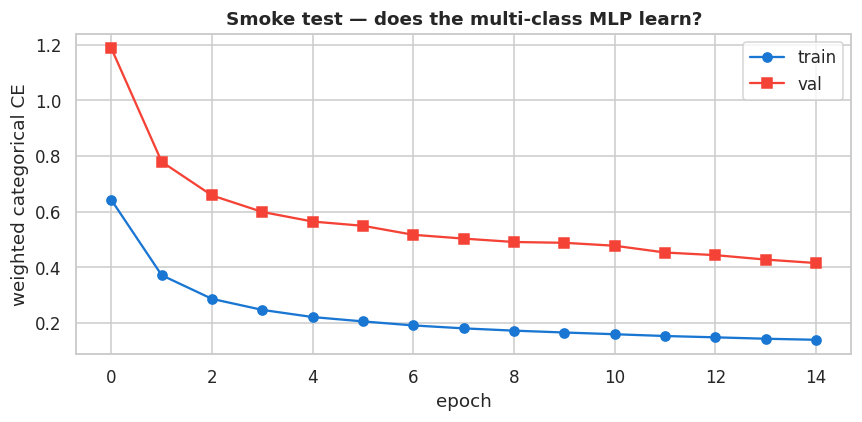

In [4]:
_t = time.time()
_smoke = MLPMulticlassScratch(input_dim=n_features, n_classes=N_CLASSES,
                              hidden_sizes=(64, 32), lr=0.01, lambda_=0.0,
                              dropout=0.2, batch_size=8192, epochs=15,
                              class_weight=True, verbose=True)
_smoke.fit(X_tr, y_tr, X_val, y_val)
_val_macro_f1 = f1_score(y_val, _smoke.predict(X_val), average='macro')

_log('')
_log('── SECTION 4 : MULTI-CLASS MLP SMOKE TEST ─────────────────')
_log(f'  Architecture        : [{n_features} -> 64 -> 32 -> {N_CLASSES}]')
_log(f'  Parameter count     : {_smoke.n_params():,}')
_log(f'  Defaults (lr=0.01, dropout=0.2, lambda=0, batch=8192, epochs=15)')
_log(f'  Validation MACRO-F1 : {_val_macro_f1:.4f}   (fit took {time.time()-_t:.1f}s)')
_log(f'  Loss : {_smoke.history["train_loss"][0]:.4f} -> {_smoke.history["train_loss"][-1]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(_smoke.history['train_loss'], 'o-', label='train', color='#1976D2')
ax.plot(_smoke.history['val_loss'],  's-', label='val',   color='#F44336')
ax.set_xlabel('epoch'); ax.set_ylabel('weighted categorical CE')
ax.set_title('Smoke test — does the multi-class MLP learn?', fontweight='bold')
ax.legend()
plt.tight_layout()
_savefig('01_smoke_test.png', fig)
plt.show()

## 5. Hyperparameter Tuning — Grid Search (Macro-F1)
Same grid as the binary MLP, but with two tweaks informed by what we already learned:

1. **Dropout fixed at 0.0.** In the binary MLP grid, dropout *hurt* every configuration. Multi-class has even more rare-class signal we don't want to randomly drop, so we skip it.
2. **Wider architecture tested.** Multi-class has 7-way output instead of 1, so deeper representations may help more.

| Hyperparameter | Grid |
|---|---|
| `hidden_sizes` | (64,32), (128,64), (256,128) |
| `lr` | 0.01, 0.05 |
| `dropout` | 0.0 (fixed) |
| `lambda_` | 0.0 (fixed) |

That's 3 × 2 = **6 fits at 25 epochs**. Ranked by validation **macro-F1**. Tuning on real-distribution data with class weighting (same as the softmax-LR notebook) so the grid search isn't biased by SMOTE.

In [5]:
param_grid = {
    'hidden_sizes': [(64, 32), (128, 64), (256, 128)],
    'lr':           [0.01, 0.05],
}
GRID_EPOCHS = 25
BATCH_SIZE  = 4096

results, histories = [], {}
n_fits = len(param_grid['hidden_sizes']) * len(param_grid['lr'])

_log('')
_log('── SECTION 5 : GRID SEARCH (ranked by macro-F1) ───────────')
_log(f'  Grid: {n_fits} fits at {GRID_EPOCHS} epochs each, batch_size={BATCH_SIZE}')

t_all = time.time()
for hs in param_grid['hidden_sizes']:
    for lr in param_grid['lr']:
        t0 = time.time()
        model = MLPMulticlassScratch(
            input_dim=n_features, n_classes=N_CLASSES, hidden_sizes=hs,
            lr=lr, lambda_=0.0, dropout=0.0, batch_size=BATCH_SIZE,
            epochs=GRID_EPOCHS, class_weight=True, random_state=RANDOM_SEED)
        model.fit(X_tr, y_tr, X_val, y_val)
        yv = model.predict(X_val)
        row = {
            'hidden_sizes':   str(hs),
            'lr':             lr,
            'val_macro_f1':   f1_score(y_val, yv, average='macro'),
            'val_weighted_f1':f1_score(y_val, yv, average='weighted'),
            'val_accuracy':   accuracy_score(y_val, yv),
            'final_loss':     model.history['train_loss'][-1],
            'params':         model.n_params(),
            'fit_seconds':    time.time() - t0,
        }
        results.append(row)
        histories[(str(hs), lr)] = model.history
        _log(f'  hs={str(hs):<11} lr={lr:<5} -> macroF1={row["val_macro_f1"]:.4f}  '
             f'acc={row["val_accuracy"]:.4f}  ({row["fit_seconds"]:.1f}s)')

results_df = pd.DataFrame(results).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
_log('')
_log(f'  Total grid-search time : {time.time()-t_all:.1f}s')
_log('  Results (sorted by validation macro-F1):')
_log(results_df.to_string(index=False))
display(results_df)

best = results_df.iloc[0]
best_hs = eval(best.hidden_sizes)
_log('')
_log(f'  BEST CONFIG: hidden_sizes={best_hs}, lr={best.lr}')
_log(f'              val macroF1={best.val_macro_f1:.4f}  ({best.params:,} params)')


── SECTION 5 : GRID SEARCH (ranked by macro-F1) ───────────
  Grid: 6 fits at 25 epochs each, batch_size=4096
  hs=(64, 32)    lr=0.01  -> macroF1=0.6718  acc=0.9436  (196.4s)
  hs=(64, 32)    lr=0.05  -> macroF1=0.7465  acc=0.9701  (195.0s)
  hs=(128, 64)   lr=0.01  -> macroF1=0.6951  acc=0.9513  (329.0s)
  hs=(128, 64)   lr=0.05  -> macroF1=0.7667  acc=0.9725  (328.0s)
  hs=(256, 128)  lr=0.01  -> macroF1=0.6998  acc=0.9542  (661.9s)
  hs=(256, 128)  lr=0.05  -> macroF1=0.7591  acc=0.9730  (676.8s)

  Total grid-search time : 2387.0s
  Results (sorted by validation macro-F1):
hidden_sizes     lr  val_macro_f1  val_weighted_f1  val_accuracy  final_loss  params  fit_seconds
   (128, 64) 0.0500        0.7667           0.9810        0.9725      0.0307   14855     327.9628
  (256, 128) 0.0500        0.7591           0.9813        0.9730      0.0291   46087     676.7868
    (64, 32) 0.0500        0.7465           0.9793        0.9701      0.0336    5383     194.9803
  (256, 128) 0.0100   

,hidden_sizes,lr,val_macro_f1,val_weighted_f1,val_accuracy,final_loss,params,fit_seconds
0,"(128, 64)",0.0500,0.7667,0.9810,0.9725,0.0307,14855,327.9628
1,"(256, 128)",0.0500,0.7591,0.9813,0.9730,0.0291,46087,676.7868
2,"(64, 32)",0.0500,0.7465,0.9793,0.9701,0.0336,5383,194.9803
3,"(256, 128)",0.0100,0.6998,0.9678,0.9542,0.0476,46087,661.8632
4,"(128, 64)",0.0100,0.6951,0.9661,0.9513,0.0519,14855,328.9888
5,"(64, 32)",0.0100,0.6718,0.9593,0.9436,0.0630,5383,196.4259



  BEST CONFIG: hidden_sizes=(128, 64), lr=0.05
              val macroF1=0.7667  (14,855 params)


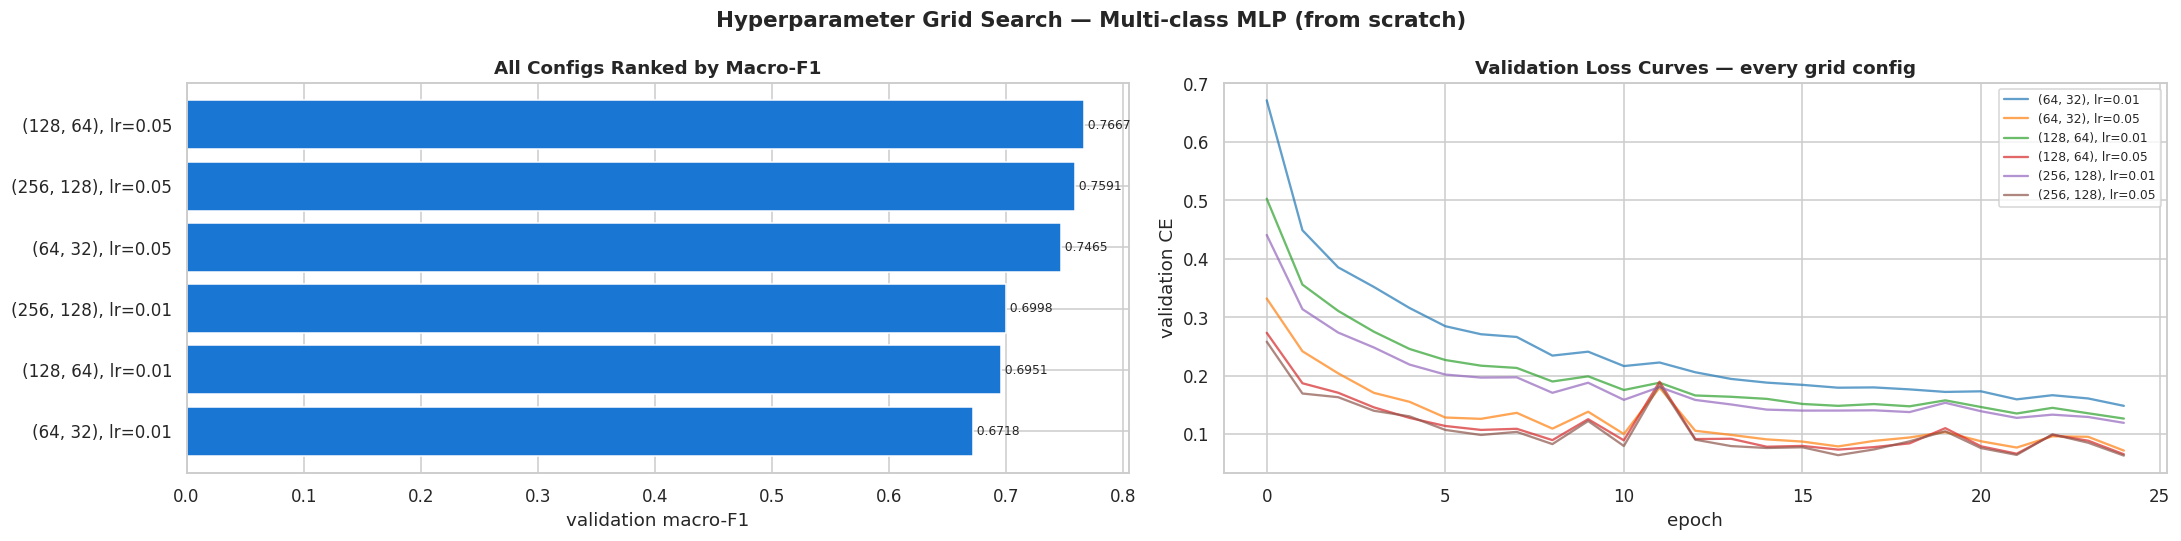

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# bar: macro-F1 by config
ax = axes[0]
for_plot = results_df.copy()
for_plot['config'] = for_plot['hidden_sizes'].astype(str) + ', lr=' + for_plot['lr'].astype(str)
for_plot = for_plot.sort_values('val_macro_f1')
ax.barh(for_plot['config'], for_plot['val_macro_f1'], color='#1976D2')
ax.set_xlabel('validation macro-F1')
ax.set_title('All Configs Ranked by Macro-F1', fontweight='bold')
for i, v in enumerate(for_plot['val_macro_f1']):
    ax.text(v, i, f' {v:.4f}', va='center', fontsize=8)

# loss curves
ax = axes[1]
for (hs, lr), hist in histories.items():
    ax.plot(hist['val_loss'], alpha=0.7, label=f'{hs}, lr={lr}')
ax.set_xlabel('epoch'); ax.set_ylabel('validation CE')
ax.set_title('Validation Loss Curves — every grid config', fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('Hyperparameter Grid Search — Multi-class MLP (from scratch)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
_savefig('02_grid_search.png', fig)
plt.show()

## 6. SMOTE vs Class-Weighting — Final Models
Retrain the best config two ways, evaluate on the held-out real-world test set.

In the softmax-LR multi-class run, SMOTE won decisively (macro-F1 0.7527 vs 0.6582 — a +0.094 gap). The interesting question: **does the MLP's extra capacity narrow that gap?** If the MLP can model rare-class boundaries directly from re-weighted real data, SMOTE's synthetic samples become less necessary.

In [7]:
best_hs   = eval(best.hidden_sizes)
best_lr   = float(best.lr)
FINAL_EPOCHS = 40

def evaluate_multi(model, X, y):
    pred = model.predict(X)
    return {
        'accuracy':    accuracy_score(y, pred),
        'macro_f1':    f1_score(y, pred, average='macro'),
        'weighted_f1': f1_score(y, pred, average='weighted'),
        'macro_prec':  precision_score(y, pred, average='macro'),
        'macro_rec':   recall_score(y, pred, average='macro'),
    }, pred

_log('')
_log('── SECTION 6 : FINAL MLP MODELS — STRATEGY A vs B ─────────')
_log(f'  Best config: hidden={best_hs}, lr={best_lr}, epochs={FINAL_EPOCHS}, batch={BATCH_SIZE}')

# A : real data + class weighting
_log('')
_log('  [A] Class weighting — training on real-distribution data ...')
t0 = time.time()
mlp_A = MLPMulticlassScratch(
    input_dim=n_features, n_classes=N_CLASSES, hidden_sizes=best_hs,
    lr=best_lr, lambda_=0.0, dropout=0.0, batch_size=BATCH_SIZE,
    epochs=FINAL_EPOCHS, class_weight=True, random_state=RANDOM_SEED)
mlp_A.fit(X_train_full, y_train_full, X_test, y_test)
metrics_A, pred_A = evaluate_multi(mlp_A, X_test, y_test)
_log(f'      done in {time.time()-t0:.1f}s')

# B : SMOTE data, no class weighting
_log('  [B] SMOTE — training on capped synthetic-balanced data ...')
t0 = time.time()
mlp_B = MLPMulticlassScratch(
    input_dim=n_features, n_classes=N_CLASSES, hidden_sizes=best_hs,
    lr=best_lr, lambda_=0.0, dropout=0.0, batch_size=BATCH_SIZE,
    epochs=FINAL_EPOCHS, class_weight=False, random_state=RANDOM_SEED)
mlp_B.fit(X_smote, y_smote, X_test, y_test)
metrics_B, pred_B = evaluate_multi(mlp_B, X_test, y_test)
_log(f'      done in {time.time()-t0:.1f}s')

cmp_df = pd.DataFrame({'A_class_weight': metrics_A, 'B_smote': metrics_B})
cmp_df['difference'] = cmp_df['B_smote'] - cmp_df['A_class_weight']
cmp_df['winner'] = np.where(cmp_df['difference'].abs() < 1e-4, 'tie',
                            np.where(cmp_df['difference'] > 0, 'B_smote', 'A_class_weight'))

_log('')
_log('  TEST-SET COMPARISON (real-world distribution):')
_log(cmp_df.to_string())
display(cmp_df)

f1_A_mlp = metrics_A['macro_f1']
f1_B_mlp = metrics_B['macro_f1']
overall = 'B (SMOTE)' if f1_B_mlp > f1_A_mlp else 'A (class weighting)'
_log('')
_log(f'  Overall winner by MACRO-F1 : {overall}')
_log(f'    A class-weight macro-F1 = {f1_A_mlp:.4f}  |  B SMOTE macro-F1 = {f1_B_mlp:.4f}')
print(f'\nWinner by macro-F1: {overall}')


── SECTION 6 : FINAL MLP MODELS — STRATEGY A vs B ─────────
  Best config: hidden=(128, 64), lr=0.05, epochs=40, batch=4096

  [A] Class weighting — training on real-distribution data ...
      done in 707.9s
  [B] SMOTE — training on capped synthetic-balanced data ...
      done in 982.6s

  TEST-SET COMPARISON (real-world distribution):
             A_class_weight  B_smote  difference          winner
accuracy             0.9789   0.9924      0.0135         B_smote
macro_f1             0.7843   0.8439      0.0595         B_smote
weighted_f1          0.9862   0.9944      0.0082         B_smote
macro_prec           0.7477   0.8070      0.0593         B_smote
macro_rec            0.9891   0.9878     -0.0013  A_class_weight


,A_class_weight,B_smote,difference,winner
accuracy,0.9789,0.9924,0.0135,B_smote
macro_f1,0.7843,0.8439,0.0595,B_smote
weighted_f1,0.9862,0.9944,0.0082,B_smote
macro_prec,0.7477,0.8070,0.0593,B_smote
macro_rec,0.9891,0.9878,-0.0013,A_class_weight



  Overall winner by MACRO-F1 : B (SMOTE)
    A class-weight macro-F1 = 0.7843  |  B SMOTE macro-F1 = 0.8439

Winner by macro-F1: B (SMOTE)


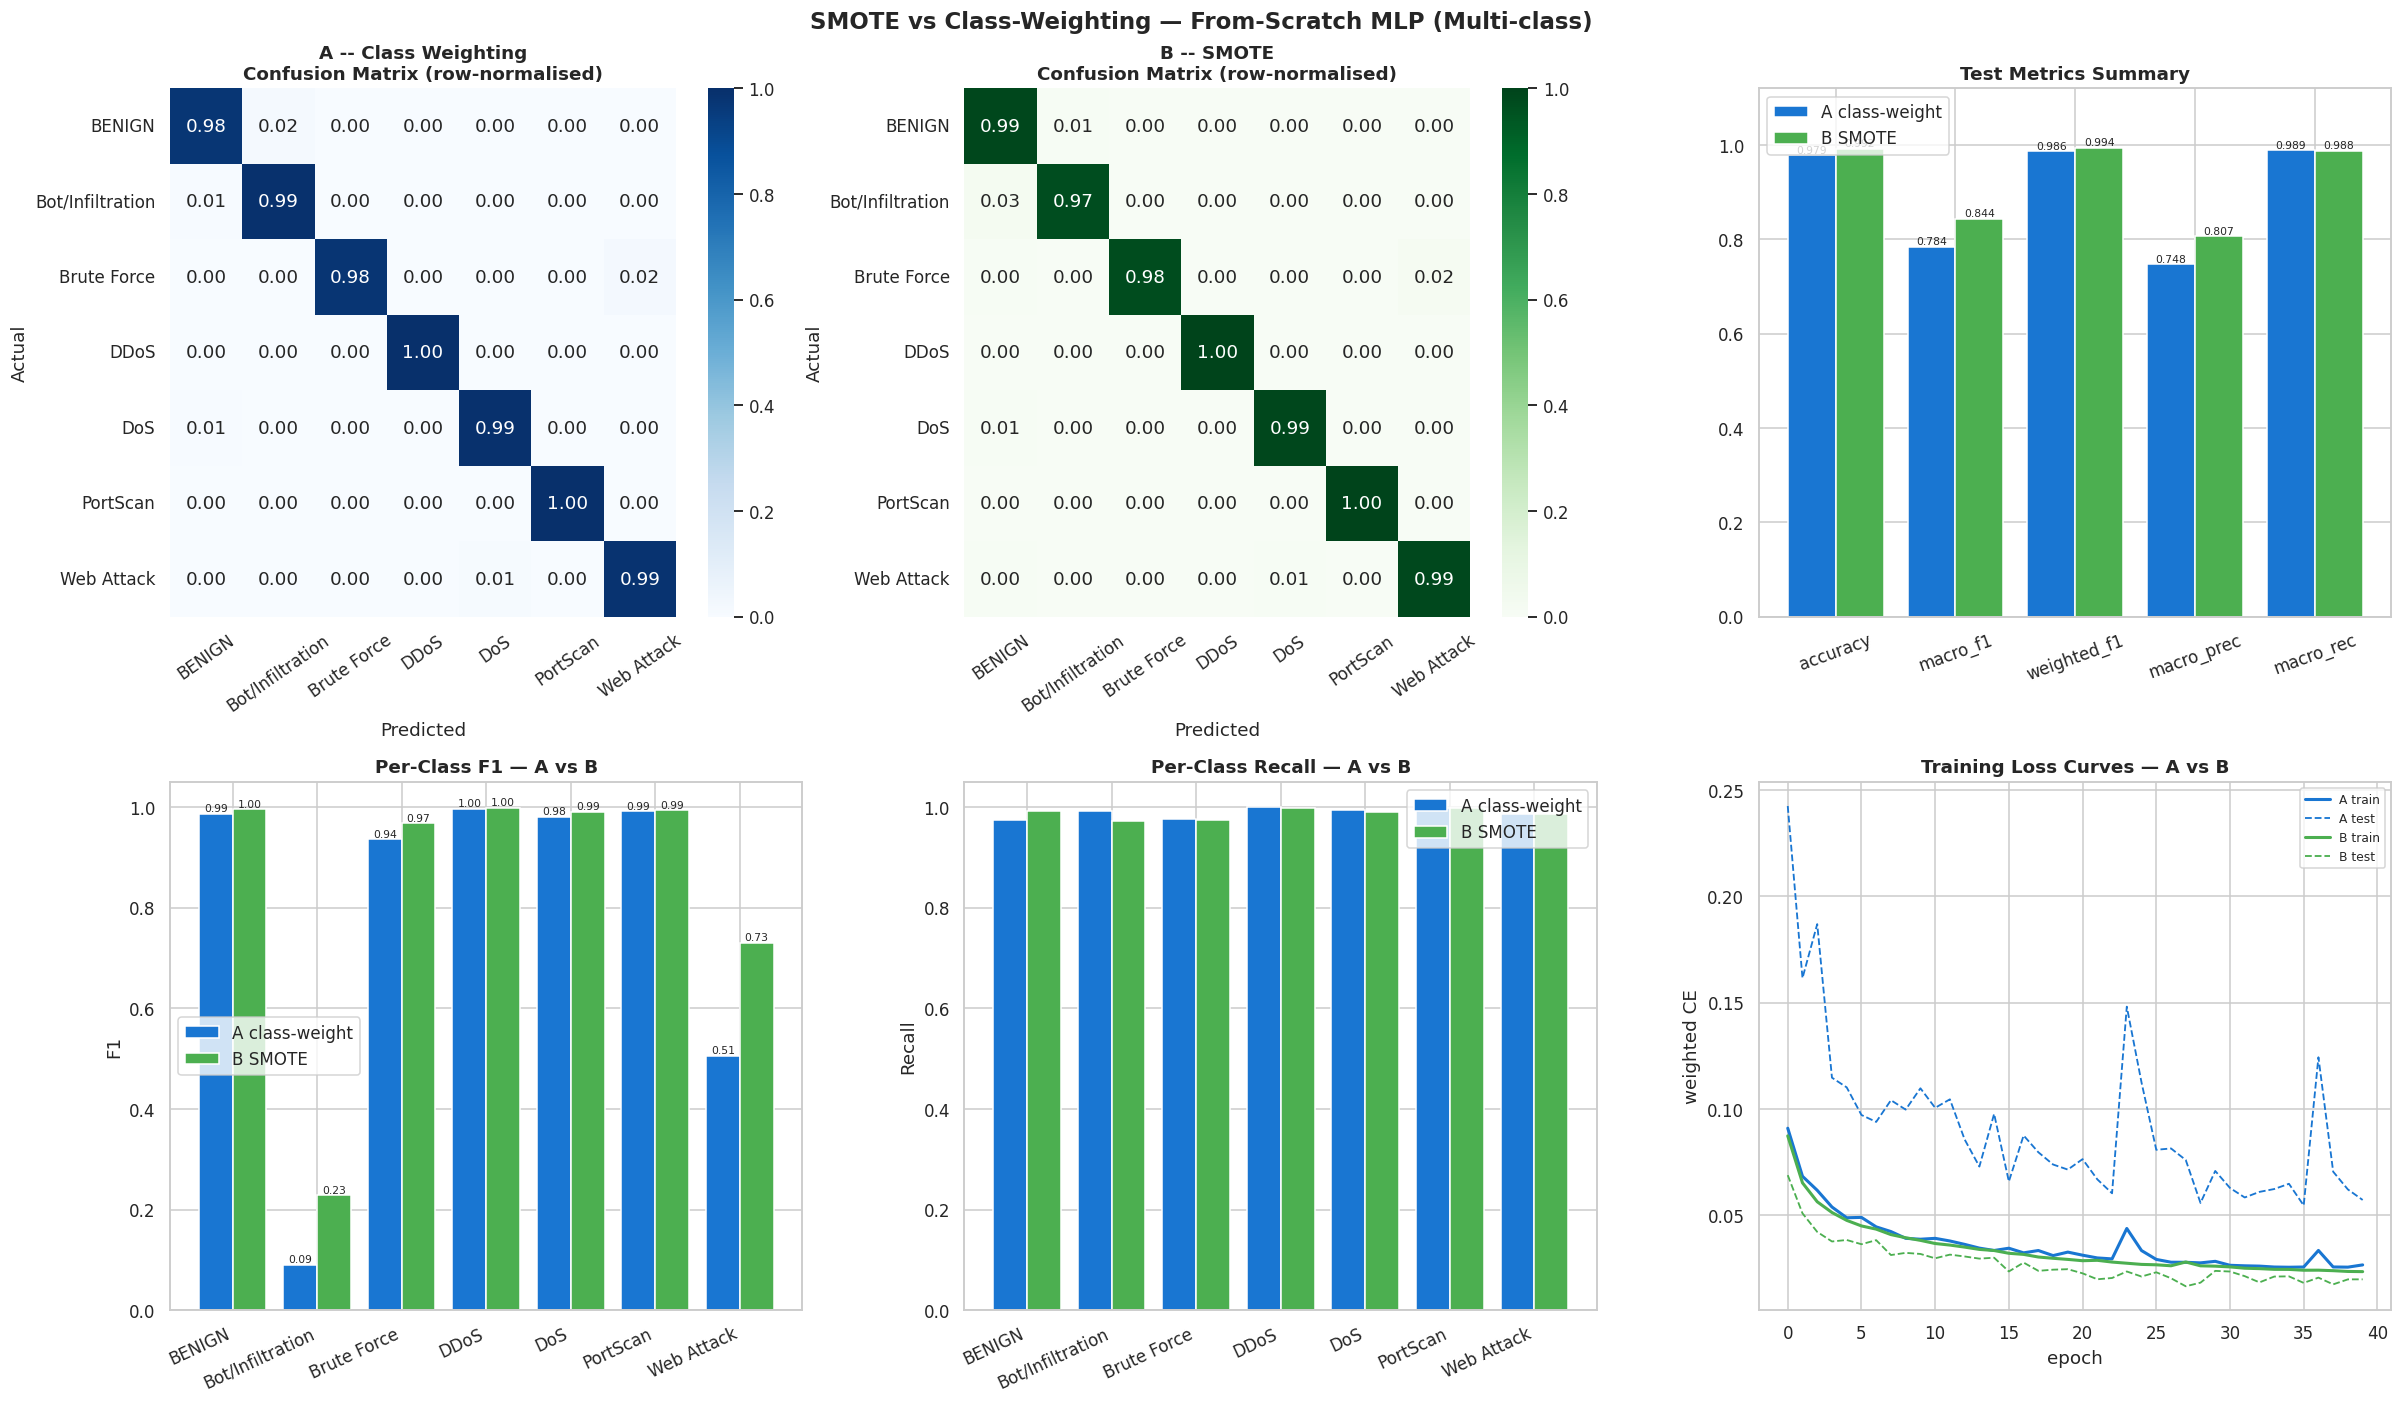

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# confusion matrix A (row-normalised = recall per class)
cm_A      = confusion_matrix(y_test, pred_A)
cm_A_norm = cm_A.astype(float) / cm_A.sum(axis=1, keepdims=True)
sns.heatmap(cm_A_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
axes[0, 0].set_title('A -- Class Weighting\nConfusion Matrix (row-normalised)', fontweight='bold')
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')
axes[0, 0].tick_params(axis='x', rotation=35)

# confusion matrix B
cm_B      = confusion_matrix(y_test, pred_B)
cm_B_norm = cm_B.astype(float) / cm_B.sum(axis=1, keepdims=True)
sns.heatmap(cm_B_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[0, 1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
axes[0, 1].set_title('B -- SMOTE\nConfusion Matrix (row-normalised)', fontweight='bold')
axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')
axes[0, 1].tick_params(axis='x', rotation=35)

# overall metric bars
ax = axes[0, 2]
metric_names = ['accuracy', 'macro_f1', 'weighted_f1', 'macro_prec', 'macro_rec']
xx = np.arange(len(metric_names))
ax.bar(xx - 0.2, [metrics_A[m] for m in metric_names], 0.4,
       label='A class-weight', color='#1976D2')
ax.bar(xx + 0.2, [metrics_B[m] for m in metric_names], 0.4,
       label='B SMOTE', color='#4CAF50')
ax.set_xticks(xx); ax.set_xticklabels(metric_names, rotation=20)
ax.set_ylim(0, 1.12)
ax.set_title('Test Metrics Summary', fontweight='bold'); ax.legend()
for i, m in enumerate(metric_names):
    ax.text(i - 0.2, metrics_A[m], f'{metrics_A[m]:.3f}', ha='center', va='bottom', fontsize=7)
    ax.text(i + 0.2, metrics_B[m], f'{metrics_B[m]:.3f}', ha='center', va='bottom', fontsize=7)

# per-class F1
ax = axes[1, 0]
f1_A_pc = f1_score(y_test, pred_A, average=None)
f1_B_pc = f1_score(y_test, pred_B, average=None)
xx = np.arange(N_CLASSES)
ax.bar(xx - 0.2, f1_A_pc, 0.4, label='A class-weight', color='#1976D2')
ax.bar(xx + 0.2, f1_B_pc, 0.4, label='B SMOTE', color='#4CAF50')
ax.set_xticks(xx); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('F1'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 — A vs B', fontweight='bold'); ax.legend()
for i, (a, b) in enumerate(zip(f1_A_pc, f1_B_pc)):
    ax.text(i - 0.2, a, f'{a:.2f}', ha='center', va='bottom', fontsize=7)
    ax.text(i + 0.2, b, f'{b:.2f}', ha='center', va='bottom', fontsize=7)

# per-class recall
ax = axes[1, 1]
rec_A_pc = recall_score(y_test, pred_A, average=None)
rec_B_pc = recall_score(y_test, pred_B, average=None)
ax.bar(xx - 0.2, rec_A_pc, 0.4, label='A class-weight', color='#1976D2')
ax.bar(xx + 0.2, rec_B_pc, 0.4, label='B SMOTE', color='#4CAF50')
ax.set_xticks(xx); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class Recall — A vs B', fontweight='bold'); ax.legend()

# loss curves
ax = axes[1, 2]
ax.plot(mlp_A.history['train_loss'], color='#1976D2', lw=2, label='A train')
ax.plot(mlp_A.history['val_loss'],   color='#1976D2', lw=1.2, ls='--', label='A test')
ax.plot(mlp_B.history['train_loss'], color='#4CAF50', lw=2, label='B train')
ax.plot(mlp_B.history['val_loss'],   color='#4CAF50', lw=1.2, ls='--', label='B test')
ax.set_xlabel('epoch'); ax.set_ylabel('weighted CE')
ax.set_title('Training Loss Curves — A vs B', fontweight='bold'); ax.legend(fontsize=8)

plt.suptitle('SMOTE vs Class-Weighting — From-Scratch MLP (Multi-class)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_savefig('03_smote_vs_classweight.png', fig)
plt.show()

## 7. The Headline — Softmax LR vs MLP (Multi-class)
Direct comparison to the previous multi-class winner (Softmax LR + SMOTE, macro-F1 0.7527). The two failure cases to watch:

- **Web Attack** (429 test rows): LR managed F1 = 0.408 (precision 0.26)
- **Bot/Infiltration** (398 test rows): LR managed F1 = 0.073 (precision 0.04)

These are exactly the cases non-linearity should help with.


── SECTION 7 : MLP vs SOFTMAX LR (HEADLINE) ───────────────
  LR baseline : SMOTE-winning softmax LR from Modeling_Multiclass.ipynb
  MLP entry   : strategy B_smote  (winner of Section 6)

  OVERALL:
             LR_scratch  MLP_scratch  delta_MLP_minus_LR
accuracy         0.9704       0.9924              0.0220
macro_f1         0.7527       0.8439              0.0912
weighted_f1      0.9798       0.9944              0.0146
macro_prec       0.7142       0.8070              0.0928
macro_rec        0.9771       0.9878              0.0107

  PER-CLASS F1:
                  LR_F1  MLP_F1  delta
BENIGN           0.9823  0.9955 0.0132
Bot/Infiltration 0.0727  0.2291 0.1564
Brute Force      0.8616  0.9685 0.1069
DDoS             0.9966  0.9987 0.0021
DoS              0.9571  0.9914 0.0343
PortScan         0.9900  0.9934 0.0034
Web Attack       0.4084  0.7306 0.3222


,LR_scratch,MLP_scratch,delta_MLP_minus_LR
accuracy,0.9704,0.9924,0.0220
macro_f1,0.7527,0.8439,0.0912
weighted_f1,0.9798,0.9944,0.0146
macro_prec,0.7142,0.8070,0.0928
macro_rec,0.9771,0.9878,0.0107


,LR_F1,MLP_F1,delta
BENIGN,0.9823,0.9955,0.0132
Bot/Infiltration,0.0727,0.2291,0.1564
Brute Force,0.8616,0.9685,0.1069
DDoS,0.9966,0.9987,0.0021
DoS,0.9571,0.9914,0.0343
PortScan,0.9900,0.9934,0.0034
Web Attack,0.4084,0.7306,0.3222


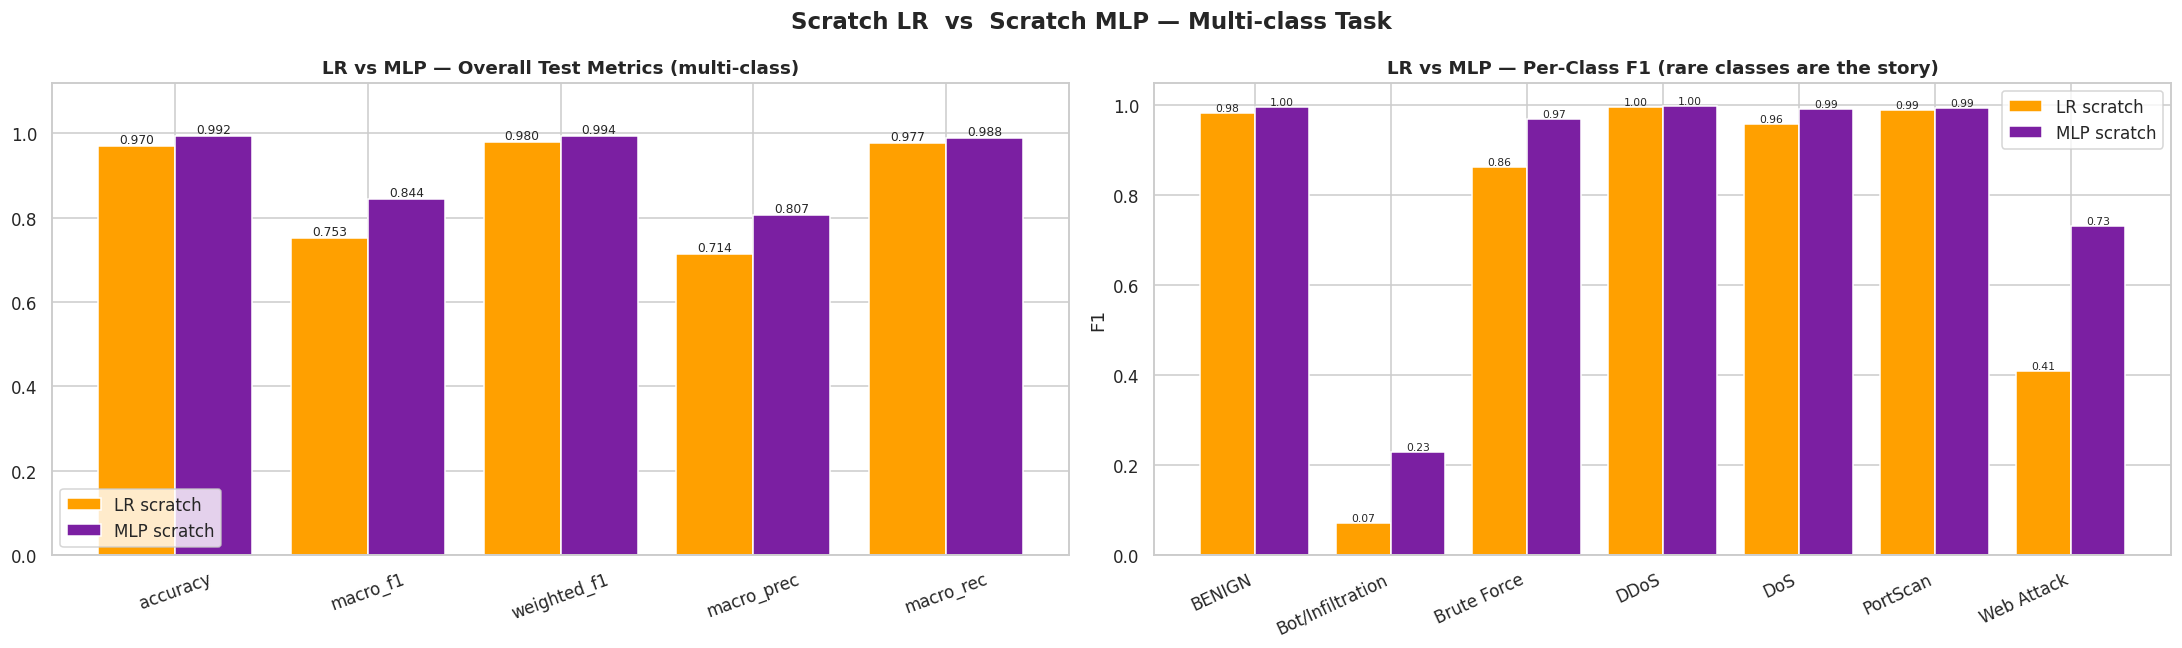


  Classification report (winning MLP):
                  precision    recall  f1-score   support

          BENIGN     0.9991    0.9919    0.9955    429677
Bot/Infiltration     0.1298    0.9724    0.2291       398
     Brute Force     0.9617    0.9754    0.9685      1830
            DDoS     0.9982    0.9992    0.9987     25603
             DoS     0.9918    0.9909    0.9914     38752
        PortScan     0.9879    0.9990    0.9934     18164
      Web Attack     0.5802    0.9860    0.7306       429

        accuracy                         0.9924    514853
       macro avg     0.8070    0.9878    0.8439    514853
    weighted avg     0.9970    0.9924    0.9944    514853

                  precision    recall  f1-score   support

          BENIGN     0.9991    0.9919    0.9955    429677
Bot/Infiltration     0.1298    0.9724    0.2291       398
     Brute Force     0.9617    0.9754    0.9685      1830
            DDoS     0.9982    0.9992    0.9987     25603
             DoS     0.9918 

In [9]:
# Softmax LR baseline numbers (from Modeling_Multiclass.ipynb, SMOTE winning model)
lr_metrics_overall = {
    'accuracy':    0.9704,
    'macro_f1':    0.7527,
    'weighted_f1': 0.9798,
    'macro_prec':  0.7142,
    'macro_rec':   0.9771,
}
# Per-class F1 from the softmax-LR classification report
lr_perclass_f1 = {
    'BENIGN':           0.9823,
    'Bot/Infiltration': 0.0727,
    'Brute Force':      0.8616,
    'DDoS':             0.9966,
    'DoS':              0.9571,
    'PortScan':         0.9900,
    'Web Attack':       0.4084,
}

# pick the better MLP strategy
if metrics_B['macro_f1'] > metrics_A['macro_f1']:
    mlp_metrics, mlp_strategy = metrics_B, 'B_smote'
    final_model, final_pred = mlp_B, pred_B
    final_f1_pc = f1_B_pc
else:
    mlp_metrics, mlp_strategy = metrics_A, 'A_class_weight'
    final_model, final_pred = mlp_A, pred_A
    final_f1_pc = f1_A_pc

vs_df = pd.DataFrame({'LR_scratch': lr_metrics_overall, 'MLP_scratch': mlp_metrics})
vs_df['delta_MLP_minus_LR'] = vs_df['MLP_scratch'] - vs_df['LR_scratch']

perclass_df = pd.DataFrame({
    'LR_F1':    [lr_perclass_f1[c] for c in CLASS_NAMES],
    'MLP_F1':   final_f1_pc,
}, index=CLASS_NAMES)
perclass_df['delta'] = perclass_df['MLP_F1'] - perclass_df['LR_F1']

_log('')
_log('── SECTION 7 : MLP vs SOFTMAX LR (HEADLINE) ───────────────')
_log(f'  LR baseline : SMOTE-winning softmax LR from Modeling_Multiclass.ipynb')
_log(f'  MLP entry   : strategy {mlp_strategy}  (winner of Section 6)')
_log('')
_log('  OVERALL:')
_log(vs_df.to_string())
_log('')
_log('  PER-CLASS F1:')
_log(perclass_df.to_string())
display(vs_df)
display(perclass_df)

# headline visual
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# overall metrics
metric_names = ['accuracy', 'macro_f1', 'weighted_f1', 'macro_prec', 'macro_rec']
xx = np.arange(len(metric_names))
ax = axes[0]
ax.bar(xx - 0.2, [lr_metrics_overall[m] for m in metric_names], 0.4,
       label='LR scratch', color='#FFA000')
ax.bar(xx + 0.2, [mlp_metrics[m] for m in metric_names], 0.4,
       label='MLP scratch', color='#7B1FA2')
ax.set_xticks(xx); ax.set_xticklabels(metric_names, rotation=20)
ax.set_ylim(0, 1.12)
ax.set_title('LR vs MLP — Overall Test Metrics (multi-class)', fontweight='bold')
ax.legend()
for i, m in enumerate(metric_names):
    ax.text(i - 0.2, lr_metrics_overall[m], f'{lr_metrics_overall[m]:.3f}',
            ha='center', va='bottom', fontsize=8)
    ax.text(i + 0.2, mlp_metrics[m], f'{mlp_metrics[m]:.3f}',
            ha='center', va='bottom', fontsize=8)

# per-class F1
ax = axes[1]
xx = np.arange(N_CLASSES)
ax.bar(xx - 0.2, perclass_df['LR_F1'], 0.4, label='LR scratch', color='#FFA000')
ax.bar(xx + 0.2, perclass_df['MLP_F1'], 0.4, label='MLP scratch', color='#7B1FA2')
ax.set_xticks(xx); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('F1')
ax.set_title('LR vs MLP — Per-Class F1 (rare classes are the story)', fontweight='bold')
ax.legend()
for i in range(N_CLASSES):
    ax.text(i - 0.2, perclass_df['LR_F1'].iloc[i], f'{perclass_df["LR_F1"].iloc[i]:.2f}',
            ha='center', va='bottom', fontsize=7)
    ax.text(i + 0.2, perclass_df['MLP_F1'].iloc[i], f'{perclass_df["MLP_F1"].iloc[i]:.2f}',
            ha='center', va='bottom', fontsize=7)

plt.suptitle('Scratch LR  vs  Scratch MLP — Multi-class Task',
             fontsize=15, fontweight='bold')
plt.tight_layout()
_savefig('04_lr_vs_mlp.png', fig)
plt.show()

# final classification report on the winning MLP
report = classification_report(y_test, final_pred, target_names=CLASS_NAMES, digits=4)
_log('')
_log('  Classification report (winning MLP):')
_log(report)
print(report)

## 8. Save Models, Metrics & Report

In [10]:
# save BOTH MLP weights
p1 = os.path.join(OUT_DIR, 'mlp_scratch_multi_A_classweight.npz')
np.savez(p1, **mlp_A.params, features=np.array(selected_features),
         classes=np.array(CLASS_NAMES), hidden_sizes=np.array(best_hs),
         lr=best_lr, epochs=FINAL_EPOCHS, batch_size=BATCH_SIZE,
         strategy='A_class_weight')

p2 = os.path.join(OUT_DIR, 'mlp_scratch_multi_B_smote.npz')
np.savez(p2, **mlp_B.params, features=np.array(selected_features),
         classes=np.array(CLASS_NAMES), hidden_sizes=np.array(best_hs),
         lr=best_lr, epochs=FINAL_EPOCHS, batch_size=BATCH_SIZE,
         strategy='B_smote')

p3 = os.path.join(OUT_DIR, 'gridsearch_results_multi_mlp.csv')
results_df.to_csv(p3, index=False)

p4 = os.path.join(OUT_DIR, 'smote_vs_classweight_comparison_multi_mlp.csv')
cmp_df.to_csv(p4)

p5 = os.path.join(OUT_DIR, 'lr_vs_mlp_comparison_multi.csv')
vs_df.to_csv(p5)
perclass_df.to_csv(p5.replace('.csv', '_perclass.csv'))

p6 = os.path.join(OUT_DIR, 'final_metrics_multi_mlp.json')
with open(p6, 'w') as f:
    json.dump({
        'model': 'MLPMulticlassScratch',
        'task': 'multi-class (7 attack families)',
        'class_names': CLASS_NAMES,
        'architecture': {'input_dim': n_features, 'hidden_sizes': list(best_hs),
                         'output_dim': N_CLASSES, 'activation': 'ReLU',
                         'output_activation': 'softmax'},
        'best_hyperparameters': {'lr': best_lr, 'epochs': FINAL_EPOCHS,
                                 'batch_size': BATCH_SIZE},
        'strategy_A_class_weight': metrics_A,
        'strategy_B_smote':        metrics_B,
        'mlp_winning_strategy':    mlp_strategy,
        'softmax_lr_baseline':     lr_metrics_overall,
        'mlp_vs_lr_delta':         {m: mlp_metrics[m] - lr_metrics_overall[m]
                                    for m in lr_metrics_overall},
    }, f, indent=2)

_log('')
_log('── SECTION 8 : FILES SAVED ────────────────────────────────')
for p in [p1, p2, p3, p4, p5, p6]:
    _log(f'  {os.path.basename(p)}')
    print(f'  {os.path.basename(p)}')


── SECTION 8 : FILES SAVED ────────────────────────────────
  mlp_scratch_multi_A_classweight.npz
  mlp_scratch_multi_A_classweight.npz
  mlp_scratch_multi_B_smote.npz
  mlp_scratch_multi_B_smote.npz
  gridsearch_results_multi_mlp.csv
  gridsearch_results_multi_mlp.csv
  smote_vs_classweight_comparison_multi_mlp.csv
  smote_vs_classweight_comparison_multi_mlp.csv
  lr_vs_mlp_comparison_multi.csv
  lr_vs_mlp_comparison_multi.csv
  final_metrics_multi_mlp.json
  final_metrics_multi_mlp.json


In [11]:
_log('')
_log('=' * 70)
_log('SUMMARY  --  MULTI-CLASS MODELLING (MLP from scratch)')
_log('=' * 70)
_log(f'  Architecture     : [{n_features} -> {best_hs[0]} -> {best_hs[1]} -> {N_CLASSES}]')
_log(f'  Parameter count  : {final_model.n_params():,}')
_log(f'  Activation       : ReLU (hidden) + softmax (output)')
_log(f'  Best hyperparams : lr={best_lr}')
_log('')
_log('  IMBALANCE STRATEGY COMPARISON (test set):')
_log(f'    {"metric":<14} {"A class-weight":>16} {"B SMOTE":>16}')
for m in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_prec', 'macro_rec']:
    _log(f'    {m:<14} {metrics_A[m]:>16.4f} {metrics_B[m]:>16.4f}')
_log(f'  MLP winning strategy : {mlp_strategy}')
_log('')
_log('  SCRATCH-LR vs SCRATCH-MLP (multi-class, test set):')
_log(f'    {"metric":<14} {"LR":>10} {"MLP":>10} {"delta":>10}')
for m in ['accuracy', 'macro_f1', 'weighted_f1', 'macro_prec', 'macro_rec']:
    d = mlp_metrics[m] - lr_metrics_overall[m]
    _log(f'    {m:<14} {lr_metrics_overall[m]:>10.4f} {mlp_metrics[m]:>10.4f} {d:>+10.4f}')
_log('')
_log('  PER-CLASS F1 (rare classes are the story):')
_log(perclass_df.to_string())
_log('')
_log('  Project status: both "at least 2 from-scratch" requirements met.')
_log('  Next: library baselines (Random Forest, XGBoost).')

FIGURE_INDEX = [
    ('01_smoke_test.png',           'Smoke test: from-scratch multi-class MLP learns'),
    ('02_grid_search.png',          'Grid search across architectures and learning rates'),
    ('03_smote_vs_classweight.png', 'SMOTE vs class-weighting -- side-by-side + per-class'),
    ('04_lr_vs_mlp.png',            'Softmax LR vs MLP -- overall and per-class F1'),
]
_log('')
_log('  Figures:')
for fname, desc in FIGURE_INDEX:
    _log(f'    {fname:<32} {desc}')

write_report()

print('\n' + '=' * 55)
print('MULTI-CLASS MLP COMPLETE')
print('=' * 55)
print(f'  Best architecture     : {best_hs}')
print(f'  MLP winning strategy  : {mlp_strategy}')
print(f'  MLP test macro-F1     : {mlp_metrics["macro_f1"]:.4f}   (softmax LR was 0.7527)')
print(f'  MLP test accuracy     : {mlp_metrics["accuracy"]:.4f}   (softmax LR was 0.9704)')
print(f'  Report  -> {OUT_DIR}/Modeling_Multiclass_MLP_Report.txt')
print(f'  Figures -> {FIGURES_DIR}/  ({len(FIGURE_INDEX)} figures)')


SUMMARY  --  MULTI-CLASS MODELLING (MLP from scratch)
  Architecture     : [47 -> 128 -> 64 -> 7]
  Parameter count  : 14,855
  Activation       : ReLU (hidden) + softmax (output)
  Best hyperparams : lr=0.05

  IMBALANCE STRATEGY COMPARISON (test set):
    metric           A class-weight          B SMOTE
    accuracy                 0.9789           0.9924
    macro_f1                 0.7843           0.8439
    weighted_f1              0.9862           0.9944
    macro_prec               0.7477           0.8070
    macro_rec                0.9891           0.9878
  MLP winning strategy : B_smote

  SCRATCH-LR vs SCRATCH-MLP (multi-class, test set):
    metric                 LR        MLP      delta
    accuracy           0.9704     0.9924    +0.0220
    macro_f1           0.7527     0.8439    +0.0912
    weighted_f1        0.9798     0.9944    +0.0146
    macro_prec         0.7142     0.8070    +0.0928
    macro_rec          0.9771     0.9878    +0.0107

  PER-CLASS F1 (rare classe